In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [2]:
import zipfile

with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [5]:
import os

folder_path = "dataset/data"

files = os.listdir(folder_path)
print(len(files))   # should show 183
print(files[:10])   # show first 10 files

183
['2018-06-14.pkl', '2018-04-28.pkl', '2018-04-05.pkl', '2018-07-19.pkl', '2018-04-06.pkl', '2018-08-28.pkl', '2018-05-24.pkl', '2018-04-24.pkl', '2018-07-08.pkl', '2018-04-09.pkl']


In [6]:
import pandas as pd

file_path = os.path.join(folder_path, files[0])

df = pd.read_pickle(file_path)

df.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
709627,709627,2018-06-14 00:00:57,4512,4627,80.25,6393657,74,0,0
709628,709628,2018-06-14 00:02:39,4334,8828,28.11,6393759,74,0,0
709629,709629,2018-06-14 00:02:53,1970,5242,5.33,6393773,74,0,0
709630,709630,2018-06-14 00:03:40,2479,5264,77.12,6393820,74,0,0
709631,709631,2018-06-14 00:03:56,1157,3055,119.86,6393836,74,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9680 entries, 709627 to 719306
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TRANSACTION_ID     9680 non-null   int64         
 1   TX_DATETIME        9680 non-null   datetime64[ns]
 2   CUSTOMER_ID        9680 non-null   object        
 3   TERMINAL_ID        9680 non-null   object        
 4   TX_AMOUNT          9680 non-null   float64       
 5   TX_TIME_SECONDS    9680 non-null   object        
 6   TX_TIME_DAYS       9680 non-null   object        
 7   TX_FRAUD           9680 non-null   int64         
 8   TX_FRAUD_SCENARIO  9680 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 1014.3+ KB


In [9]:
import pandas as pd
import os

path = "dataset/data"

dataframes = []

for file in os.listdir(path):
    if file.endswith(".pkl"):
        df = pd.read_pickle(os.path.join(path, file))
        dataframes.append(df)

dataset = pd.concat(dataframes, ignore_index=True)

dataset.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,709627,2018-06-14 00:00:57,4512,4627,80.25,6393657,74,0,0
1,709628,2018-06-14 00:02:39,4334,8828,28.11,6393759,74,0,0
2,709629,2018-06-14 00:02:53,1970,5242,5.33,6393773,74,0,0
3,709630,2018-06-14 00:03:40,2479,5264,77.12,6393820,74,0,0
4,709631,2018-06-14 00:03:56,1157,3055,119.86,6393836,74,0,0


In [10]:
dataset['TX_FRAUD'].value_counts()

,count
TX_FRAUD,
0,1739474
1,14681


In [11]:
dataset['TX_DATETIME'] = pd.to_datetime(dataset['TX_DATETIME'])

In [12]:
dataset['hour'] = dataset['TX_DATETIME'].dt.hour
dataset['day'] = dataset['TX_DATETIME'].dt.day
dataset['month'] = dataset['TX_DATETIME'].dt.month

In [16]:
X = dataset[['TX_AMOUNT','CUSTOMER_ID','TERMINAL_ID','hour','day']]
y = dataset['TX_FRAUD']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9934754910483965
[[347889      0]
 [  2289    653]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    347889
           1       1.00      0.22      0.36      2942

    accuracy                           0.99    350831
   macro avg       1.00      0.61      0.68    350831
weighted avg       0.99      0.99      0.99    350831



In [21]:
import pickle

pickle.dump(model, open("fraud_detection_model.pkl", "wb"))

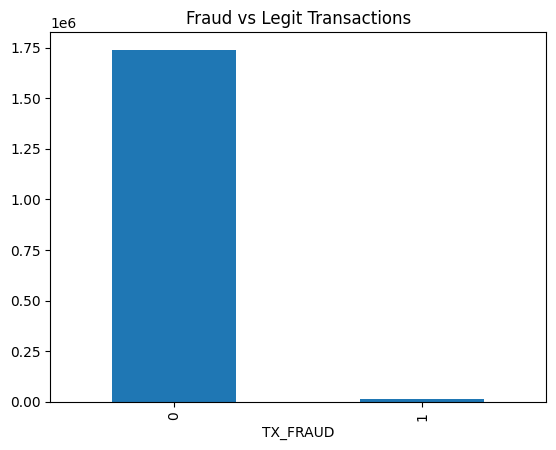

In [22]:
import matplotlib.pyplot as plt

dataset['TX_FRAUD'].value_counts().plot(kind='bar')
plt.title("Fraud vs Legit Transactions")
plt.show()